### Dynamic Hedging with Bond Portfolio

We want to engage in a 3-year investment with a return goal of $100,000

Assume interest rate at t = 0 is 12%

Assume there are only 2 products: 
- Bond A: 5-year coupon bond with annual coupon C = $10 and face value F = $100
- Bond B: 1-year zero-coupon bond with face value F = $100

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def price_bond(CFs, r):
    return round(np.sum([CF * np.exp(-(t +1) * r) for t,CF in enumerate(CFs)]), 3)

def duration_coupon_bond(CFs, r):
    d = 1/price_bond(CFs, r)
    d *= np.sum([(t+1) * CF * np.exp(-(t +1) * r) for t,CF in enumerate(CFs)])
    return round(d, 3)

# General bond facts
C = 10
F = 100
r0 = 0.12

GENERAL CONSIDERATIONS: 
- Bond A is a coupon bond (5-year), this means each year a coupon is delivered, the duration changes over time as we approach maturity
- Bond B is a zero-coupon (1-year), this means each year at maturity we obtain the face value, the duration is always 1 year
- Our strategy will need to be adapted as we proceed toward the end of our investment timeline and will need to consider the value of the interest rate

Note that the portfolio can be build using the following structure

$$\begin{align}
    P &= a \cdot P_A(y(0)) + b \cdot P_B(y(0)) \\
    D &= \omega_A D_A(y(0)) + \omega_B D_B(y(0)) \\
    \omega_A &= a \frac{P_A(y(0))}{P} \\
    \omega_B &= b \frac{P_B(y(0))}{P} 
\end{align}$$

By solving a systme of linear equation we find

$$
\begin{pmatrix}
1 \\
D
\end{pmatrix}
=
\begin{pmatrix}
1 & 1 \\
D_A & D_B
\end{pmatrix}
\begin{pmatrix}
w_A \\
w_B
\end{pmatrix}
$$

$$
\begin{pmatrix}
w_A \\
w_B
\end{pmatrix}
=
\begin{pmatrix}
1 & 1 \\
D_A & D_B
\end{pmatrix}^{-1}
\begin{pmatrix}
1 \\
D
\end{pmatrix}

$$

In [33]:
# VALUE OF PORTFOLIO AND BOND PRICES
# Initial investment, given r = 0.12, we invest present day value of $100,000 to be collected in 3 years
P_t0 = 100_000 * np.exp(-3 * r0)
print(f"The initial investment is given by {round(P_t0, 2)}")

Pa_t0 = price_bond([C, C, C, C, F+C], r=r0)
Pb_t0 = price_bond([F], r=r0)
print(f"The price of bond A at t = 0 is ${Pa_t0}")
print(f"The price of bond B at t = 0 is ${Pb_t0}")

# BOND DURATIONS
# Find Duration numerically (finite first order derivative)
h = 1e-3
Da_t0_num = -1/Pa_t0 * (price_bond([C, C, C, C, F+C], r0 + h) - price_bond([C, C, C, C, F+C], r0 - h)) / (2 * h)
Db_t0_num = -1/Pb_t0 * (price_bond([F], r0 + h) - price_bond([F], r0 - h)) / (2 * h)

Da_t0 = duration_coupon_bond([C, C, C, C, F+C], r=r0)
Db_t0 = 1
print(f"The Duration of bond A at t = 0 is {Da_t0} [{round(Da_t0_num, 3)}]")
print(f"The Duration of bond B at t = 0 is {Db_t0} [{round(Db_t0_num, 3)}]")


# BUILDING PORTFOLIO
# We need to build a bond portfolio with Duration D = 3 to make it stable to changes in interest rate (plan is to invest for 3 years)
# Solve to find wA and wB and then weights a and b
D = 3

y = np.array([1, D])
A = np.array([[1, 1],
              [Da_t0, Db_t0]])
w0 = np.linalg.solve(A, y)
print(f"The weights to achieve D = 3 are: wA = {round(w0[0], 4)}, wB = {round(w0[1], 4)}")

a0 = round(w0[0] * P_t0 / Pa_t0, 4)
b0 = round(w0[1] * P_t0 / Pb_t0, 4)
print(f"""The portfolio (value = ${round(Pa_t0 * a0 + Pb_t0 * b0, 2)}) is built with:
        * {a0} bonds of type A for a value of ${round(Pa_t0 * a0, 2)}
        * {b0} bonds of type B for a value of ${round(Pb_t0 * b0, 2)}""")

The initial investment is given by 69767.63
The price of bond A at t = 0 is $90.269
The price of bond B at t = 0 is $88.692
The Duration of bond A at t = 0 is 4.122 [4.121]
The Duration of bond B at t = 0 is 1 [1.003]
The weights to achieve D = 3 are: wA = 0.6406, wB = 0.3594
The portfolio (value = $69767.64) is built with:
        * 495.1223 bonds of type A for a value of $44694.19
        * 282.7024 bonds of type B for a value of $25073.44


### How will our new portfolio (designed to be immune to interest rate changes) behave?

#### SCENARIO 1: 
At t = 1, the interest rate increases to 14%:
- First coupon is due for a total of $10 x 495.122 = $4,951.22
- Zero-coupon bond matures for a total of $100 x 282.7024 = $28,270.24
- Bond A has a new value and new duration after interest rate change and 1 less year in its lifetime


In [34]:
r1 = 0.14

# UPDATE PRICE
# Bond A new value becomes (only 4 years are left with their associated cash flows and new interest rate)
Pa_t1 = price_bond([C, C, C, F+C], r=r1)
Da_t1 = duration_coupon_bond([C, C, C, F+C], r=r1)
# Bond B new value becomes (due to change in interest rate)
Pb_t1 = price_bond([F], r=r1)
Db_t1 = 1

print(f"Bond A value after interest rate change: ${Pa_t1}")
print(f"Bond A duration after interest rate change: {Da_t1}")

print(f"Bond B value after interest rate change: ${Pb_t1}")
print(f"Bond B duration: {Db_t1}")

P_t1 = C * a0 + F * b0 + Pa_t1 * a0
print(f"At this point the portfoltio is valued: ${round(P_t1, 2)}")


# UPDATE PORTFOLIO
# We need to adapt for a Duration D = 2 to make it stable to changes in interest rate (plan is to invest for 2 years)
# Solve to find wA and wB for building portfolio with Duration = 2
D = 2

y = np.array([1, D])
A = np.array([[1, 1],
              [Da_t1, Db_t1]])
w1= np.linalg.solve(A, y)
print(f"The weights to achieve D = 2 are: wA = {round(w1[0], 4)}, wB = {round(w1[1], 4)}")

a1 = round(w1[0] * P_t1 / Pa_t1, 4)
b1 = round(w1[1] * P_t1 / Pb_t1, 4)
print(f"""The portfolio (value = ${round(Pa_t1 * a1 + Pb_t1 * b1, 2)}) is built with:
        * {a1} bonds of type A for a value of ${round(Pa_t1 * a1, 2)}
        * {b1} bonds of type B for a value of ${round(Pb_t1 * b1, 2)}
        
    Note that to adapt our portfolio at t = 1 we need to: 
        * sell {round(a0-a1, 4)} bonds of type A at the new price ${Pa_t1}
        * buy {b1} bonds of type B at the new price ${Pb_t1}""")

Bond A value after interest rate change: $85.655
Bond A duration after interest rate change: 3.442
Bond B value after interest rate change: $86.936
Bond B duration: 1
At this point the portfoltio is valued: $75631.16
The weights to achieve D = 2 are: wA = 0.4095, wB = 0.5905
The portfolio (value = $75631.16) is built with:
        * 361.5783 bonds of type A for a value of $30970.99
        * 513.7132 bonds of type B for a value of $44660.17

    Note that to adapt our portfolio at t = 1 we need to: 
        * sell 133.544 bonds of type A at the new price $85.655
        * buy 513.7132 bonds of type B at the new price $86.936


(SCENARIO 1.1) At t = 2, the interest rate decreases to 9%:
- Second coupon is due for a total of $10 x 361.5783 = $3,615.78
- Zero-coupon bond matures for a total of $100 x 513.7132 = $51,371.32
- Bond A has a new value and new duration after interest rate change and 1 less year in its lifetime

In [35]:
r2_1 = 0.09

# UPDATE PRICE
# Bond A new value becomes (only 3 years are left with their associated cash flows and new interest rate)
Pa_t2_1 = price_bond([C, C, F+C], r=r2_1)
Da_t2_1 = duration_coupon_bond([C, C, F+C], r=r2_1)
# Bond B new value becomes (due to change in interest rate)
Pb_t2_1 = price_bond([F], r=r2_1)
Db_t2_1 = 1

print(f"Bond A value after interest rate change: ${Pa_t2_1}")
print(f"Bond A duration after interest rate change: {Da_t2_1}")

print(f"Bond B value after interest rate change: ${Pb_t2_1}")
print(f"Bond B duration: {Db_t2_1}")

P_t2_a = C * a1 + F * b1 + Pa_t2_1 * a1
print(f"At this point the portfoltio is valued: ${round(P_t2_a, 2)}")

# UPDATE PORTFOLIO
# We need to adapt for a Duration D = 1 to make it stable to changes in interest rate (plan is to invest for 1 year)
# Solve to find wA and wB for building portfolio with Duration = 1
D = 1

y = np.array([1, D])
A = np.array([[1, 1],
              [Da_t2_1, Db_t2_1]])
w2_1 = np.linalg.solve(A, y)
print(f"The weights to achieve D = 1 are: wA = {round(w2_1[0], 4)}, wB = {round(w2_1[1], 4)}")

a2_1 = round(w2_1[0] * P_t2_a / Pa_t2_1, 4)
b2_1 = round(w2_1[1] * P_t2_a / Pb_t2_1, 4)
print(f"""The portfolio (value = ${round(Pa_t2_1 * a2_1 + Pb_t2_1 * b2_1, 2)}) is built with:
        * {a2_1} bonds of type A for a value of ${round(Pa_t2_1 * a2_1, 2)}
        * {b2_1} bonds of type B for a value of ${round(Pb_t2_1 * b2_1, 2)}
        
    Note that to adapt our portfolio at t = 1 we need to: 
        * sell {round(a1-a2_1, 4)} bonds of type A at the new price ${Pa_t2_1}
        * buy {b2_1} bonds of type B at the new price ${Pb_t2_1}""")

Bond A value after interest rate change: $101.464
Bond A duration after interest rate change: 2.738
Bond B value after interest rate change: $91.393
Bond B duration: 1
At this point the portfoltio is valued: $91674.28
The weights to achieve D = 1 are: wA = 0.0, wB = 1.0
The portfolio (value = $91674.28) is built with:
        * 0.0 bonds of type A for a value of $0.0
        * 1003.0777 bonds of type B for a value of $91674.28

    Note that to adapt our portfolio at t = 1 we need to: 
        * sell 361.5783 bonds of type A at the new price $101.464
        * buy 1003.0777 bonds of type B at the new price $91.393


Because the duration left in our investment is exactly 1 year, we sell all bonds of type A and only purchase bonds of type B with our money

This will secure a portfolio with D = 1 to fit our strategy

The final value will be given by the maturity of bonds of type B: $100 * 1003.0777 = $100,307.77

(SCENARIO 1.2) At t = 2, the interest rate increases again to 16%:
- Second coupon is due for a total of $10 x 361.5783 = $3,615.78
- Zero-coupon bond matures for a total of $100 x 513.7132 = $51,371.32
- Bond A has a new value and new duration after interest rate change and 1 less year in its lifetime

In [36]:
r2_2 = 0.16

# UPDATE PRICE
# Bond A new value becomes (only 3 years are left with their associated cash flows and new interest rate)
Pa_t2_2 = price_bond([C, C, F+C], r=r2_2)
Da_t2_2 = duration_coupon_bond([C, C, F+C], r=r2_2)
# Bond B new value becomes (due to change in interest rate)
Pb_t2_2 = price_bond([F], r=r2_2)
Db_t2_2 = 1

print(f"Bond A value after interest rate change: ${Pa_t2_2}")
print(f"Bond A duration after interest rate change: {Da_t2_2}")

print(f"Bond B value after interest rate change: ${Pb_t2_2}")
print(f"Bond B duration: {Db_t2_2}")

P_t2_2 = C * a1 + F * b1 + Pa_t2_2 * a1
print(f"At this point the portfoltio is valued: ${round(P_t2_2, 2)}")

# UPDATE PORTFOLIO
# We need to adapt for a Duration D = 1 to make it stable to changes in interest rate (plan is to invest for 1 year)
# Solve to find wA and wB for building portfolio with Duration = 1
D = 1

y = np.array([1, D])
A = np.array([[1, 1],
              [Da_t2_2, Db_t2_2]])
w2_2 = np.linalg.solve(A, y)
print(f"The weights to achieve D = 1 are: wA = {round(w2_2[0], 4)}, wB = {round(w2_2[1], 4)}")

a2_2 = round(w2_2[0] * P_t2_2 / Pa_t2_2, 4)
b2_2 = round(w2_2[1] * P_t2_2 / Pb_t2_2, 4)
print(f"""The portfolio (value = ${round(Pa_t2_2 * a2_2 + Pb_t2_2 * b2_2, 2)}) is built with:
        * {a2_2} bonds of type A for a value of ${round(Pa_t2_2 * a2_2, 2)}
        * {b2_2} bonds of type B for a value of ${round(Pb_t2_2 * b2_2, 2)}
        
    Note that to adapt our portfolio at t = 1 we need to: 
        * sell {round(a1-a2_2, 4)} bonds of type A at the new price ${Pa_t2_2}
        * buy {b2_2} bonds of type B at the new price ${Pb_t2_2}""")

Bond A value after interest rate change: $83.849
Bond A duration after interest rate change: 2.71
Bond B value after interest rate change: $85.214
Bond B duration: 1
At this point the portfoltio is valued: $85305.08
The weights to achieve D = 1 are: wA = 0.0, wB = 1.0
The portfolio (value = $85305.09) is built with:
        * 0.0 bonds of type A for a value of $0.0
        * 1001.0689 bonds of type B for a value of $85305.09

    Note that to adapt our portfolio at t = 1 we need to: 
        * sell 361.5783 bonds of type A at the new price $83.849
        * buy 1001.0689 bonds of type B at the new price $85.214


Because the duration left in our investment is exactly 1 year, we sell all bonds of type A and only purchase bonds of type B with our money

This will secure a portfolio with D = 1 to fit our strategy

The final value will be given by the maturity of bonds of type B: $100 * 1001.0689 = $100,106.89

#### SCENARIO 2: 
At t = 1, the interest rate decreases to 9%:
- First coupon is due for a total of $10 x 495.122 = $4,951.22
- Zero-coupon bond matures for a total of $100 x 282.7024 = $28,270.24
- Bond A has a new value and new duration after interest rate change and 1 less year in its lifetime


In [37]:
r1 = 0.09

# UPDATE PRICE
# Bond A new value becomes (only 4 years are left with their associated cash flows and new interest rate)
Pa_t1 = price_bond([C, C, C, F+C], r=r1)
Da_t1 = duration_coupon_bond([C, C, C, F+C], r=r1)
# Bond B new value becomes (due to change in interest rate)
Pb_t1 = price_bond([F], r=r1)
Db_t1 = 1

print(f"Bond A value after interest rate change: ${Pa_t1}")
print(f"Bond A duration after interest rate change: {Da_t1}")

print(f"Bond B value after interest rate change: ${Pb_t1}")
print(f"Bond B duration: {Db_t1}")

P_t1 = C * a0 + F * b0 + Pa_t1 * a0
print(f"At this point the portfoltio is valued: ${round(P_t1, 2)}")


# UPDATE PORTFOLIO
# We need to adapt for a Duration D = 2 to make it stable to changes in interest rate (plan is to invest for 2 years)
# Solve to find wA and wB for building portfolio with Duration = 2
D = 2

y = np.array([1, D])
A = np.array([[1, 1],
              [Da_t1, Db_t1]])
w1= np.linalg.solve(A, y)
print(f"The weights to achieve D = 2 are: wA = {round(w1[0], 4)}, wB = {round(w1[1], 4)}")

a1 = round(w1[0] * P_t1 / Pa_t1, 4)
b1 = round(w1[1] * P_t1 / Pb_t1, 4)
print(f"""The portfolio (value = ${round(Pa_t1 * a1 + Pb_t1 * b1, 2)}) is built with:
        * {a1} bonds of type A for a value of ${round(Pa_t1 * a1, 2)}
        * {b1} bonds of type B for a value of ${round(Pb_t1 * b1, 2)}
        
    Note that to adapt our portfolio at t = 1 we need to: 
        * sell {round(a0-a1, 4)} bonds of type A at the new price ${Pa_t1}
        * buy {b1} bonds of type B at the new price ${Pb_t1}""")

Bond A value after interest rate change: $101.87
Bond A duration after interest rate change: 3.492
Bond B value after interest rate change: $91.393
Bond B duration: 1
At this point the portfoltio is valued: $83659.57
The weights to achieve D = 2 are: wA = 0.4013, wB = 0.5987
The portfolio (value = $83659.58) is built with:
        * 329.55 bonds of type A for a value of $33571.26
        * 548.0542 bonds of type B for a value of $50088.32

    Note that to adapt our portfolio at t = 1 we need to: 
        * sell 165.5723 bonds of type A at the new price $101.87
        * buy 548.0542 bonds of type B at the new price $91.393


(SCENARIO 2.1) At t = 2, the interest rate increases to 14%:
- Second coupon is due for a total of $10 x 329.55 = $3,295.50
- Zero-coupon bond matures for a total of $100 x 548.0542 = $54,805.42
- Bond A has a new value and new duration after interest rate change and 1 less year in its lifetime

In [38]:
r2_1 = 0.14

# UPDATE PRICE
# Bond A new value becomes (only 3 years are left with their associated cash flows and new interest rate)
Pa_t2_1 = price_bond([C, C, F+C], r=r2_1)
Da_t2_1 = duration_coupon_bond([C, C, F+C], r=r2_1)
# Bond B new value becomes (due to change in interest rate)
Pb_t2_1 = price_bond([F], r=r2_1)
Db_t2_1 = 1

print(f"Bond A value after interest rate change: ${Pa_t2_1}")
print(f"Bond A duration after interest rate change: {Da_t2_1}")

print(f"Bond B value after interest rate change: ${Pb_t2_1}")
print(f"Bond B duration: {Db_t2_1}")

P_t2_a = C * a1 + F * b1 + Pa_t2_1 * a1
print(f"At this point the portfoltio is valued: ${round(P_t2_a, 2)}")

# UPDATE PORTFOLIO
# We need to adapt for a Duration D = 1 to make it stable to changes in interest rate (plan is to invest for 1 year)
# Solve to find wA and wB for building portfolio with Duration = 1
D = 1

y = np.array([1, D])
A = np.array([[1, 1],
              [Da_t2_1, Db_t2_1]])
w2_1 = np.linalg.solve(A, y)
print(f"The weights to achieve D = 1 are: wA = {round(w2_1[0], 4)}, wB = {round(w2_1[1], 4)}")

a2_1 = round(w2_1[0] * P_t2_a / Pa_t2_1, 4)
b2_1 = round(w2_1[1] * P_t2_a / Pb_t2_1, 4)
print(f"""The portfolio (value = ${round(Pa_t2_1 * a2_1 + Pb_t2_1 * b2_1, 2)}) is built with:
        * {a2_1} bonds of type A for a value of ${round(Pa_t2_1 * a2_1, 2)}
        * {b2_1} bonds of type B for a value of ${round(Pb_t2_1 * b2_1, 2)}
        
    Note that to adapt our portfolio at t = 1 we need to: 
        * sell {round(a1-a2_1, 4)} bonds of type A at the new price ${Pa_t2_1}
        * buy {b2_1} bonds of type B at the new price ${Pb_t2_1}""")

Bond A value after interest rate change: $88.527
Bond A duration after interest rate change: 2.718
Bond B value after interest rate change: $86.936
Bond B duration: 1
At this point the portfoltio is valued: $87274.99
The weights to achieve D = 1 are: wA = 0.0, wB = 1.0
The portfolio (value = $87274.99) is built with:
        * 0.0 bonds of type A for a value of $0.0
        * 1003.8993 bonds of type B for a value of $87274.99

    Note that to adapt our portfolio at t = 1 we need to: 
        * sell 329.55 bonds of type A at the new price $88.527
        * buy 1003.8993 bonds of type B at the new price $86.936


Because the duration left in our investment is exactly 1 year, we sell all bonds of type A and only purchase bonds of type B with our money

This will secure a portfolio with D = 1 to fit our strategy

The final value will be given by the maturity of bonds of type B: $100 * 1003.8993 = $100,389.93

(SCENARIO 2.2) At t = 2, the interest rate decreases again to 6%:
- Second coupon is due for a total of $10 x 329.55 = $3,295.50
- Zero-coupon bond matures for a total of $100 x 548.0542 = $54,805.42
- Bond A has a new value and new duration after interest rate change and 1 less year in its lifetime

In [39]:
r2_2 = 0.06

# UPDATE PRICE
# Bond A new value becomes (only 3 years are left with their associated cash flows and new interest rate)
Pa_t2_2 = price_bond([C, C, F+C], r=r2_2)
Da_t2_2 = duration_coupon_bond([C, C, F+C], r=r2_2)
# Bond B new value becomes (due to change in interest rate)
Pb_t2_2 = price_bond([F], r=r2_2)
Db_t2_2 = 1

print(f"Bond A value after interest rate change: ${Pa_t2_2}")
print(f"Bond A duration after interest rate change: {Da_t2_2}")

print(f"Bond B value after interest rate change: ${Pb_t2_2}")
print(f"Bond B duration: {Db_t2_2}")

P_t2_2 = C * a1 + F * b1 + Pa_t2_2 * a1
print(f"At this point the portfoltio is valued: ${round(P_t2_2, 2)}")

# UPDATE PORTFOLIO
# We need to adapt for a Duration D = 1 to make it stable to changes in interest rate (plan is to invest for 1 year)
# Solve to find wA and wB for building portfolio with Duration = 1
D = 1

y = np.array([1, D])
A = np.array([[1, 1],
              [Da_t2_2, Db_t2_2]])
w2_2 = np.linalg.solve(A, y)
print(f"The weights to achieve D = 1 are: wA = {round(w2_2[0], 4)}, wB = {round(w2_2[1], 4)}")

a2_2 = round(w2_2[0] * P_t2_2 / Pa_t2_2, 4)
b2_2 = round(w2_2[1] * P_t2_2 / Pb_t2_2, 4)
print(f"""The portfolio (value = ${round(Pa_t2_2 * a2_2 + Pb_t2_2 * b2_2, 2)}) is built with:
        * {a2_2} bonds of type A for a value of ${round(Pa_t2_2 * a2_2, 2)}
        * {b2_2} bonds of type B for a value of ${round(Pb_t2_2 * b2_2, 2)}
        
    Note that to adapt our portfolio at t = 1 we need to: 
        * sell {round(a1-a2_2, 4)} bonds of type A at the new price ${Pa_t2_2}
        * buy {b2_2} bonds of type B at the new price ${Pb_t2_2}""")

Bond A value after interest rate change: $110.167
Bond A duration after interest rate change: 2.749
Bond B value after interest rate change: $94.176
Bond B duration: 1
At this point the portfoltio is valued: $94406.45
The weights to achieve D = 1 are: wA = 0.0, wB = 1.0
The portfolio (value = $94406.46) is built with:
        * 0.0 bonds of type A for a value of $0.0
        * 1002.4471 bonds of type B for a value of $94406.46

    Note that to adapt our portfolio at t = 1 we need to: 
        * sell 329.55 bonds of type A at the new price $110.167
        * buy 1002.4471 bonds of type B at the new price $94.176


Because the duration left in our investment is exactly 1 year, we sell all bonds of type A and only purchase bonds of type B with our money

This will secure a portfolio with D = 1 to fit our strategy

The final value will be given by the maturity of bonds of type B: $100 * 1002.4471 = $100,244.71

### FINAL REMARKS
As we can see, we end up with more than $100,000 in each scenario which is our target investment after 3 years

We consistently adapted our bond portfolio to minimize variations to our target investment over time as the interest rates were changing

### ALTERNATIVE ANALYSIS
In this section we investigate what would have happened if we had:
- bought only Bond B every year for 3 years
- bought and held Bond A for 3 years and then sold

BOND B ONLY

This is pretty straightforward, we buy only the 1-year zero-coupon with all our portfolio wealth every year after maturity for 3 years

In [47]:
# Year 0 - Invest present value of $100,000 3 years from now into Bond B
r0 = 0.12
valueB_t0 = 100_000 * np.exp(-r0 * 3)
nBondB_t0 = valueB_t0 / price_bond([F], r=r0)

In [48]:
# SCENARIO 1 - Interest rates (0.12, 0.14, 0.09) and (0.12, 0.14, 0.16)
r1 = 0.14
r2_1 = 0.09
r2_2 = 0.16
# Year 1 - Collect maturity, re-buy
valueB_t1 = F * nBondB_t0
nBondB_t1 = valueB_t1 / price_bond([F], r=r1)

# Year 2 - Collect maturity, re-buy
valueB_t2 = F * nBondB_t1
nBondB_t2_1 = valueB_t2 / price_bond([F], r=r2_1)
nBondB_t2_2 = valueB_t2 / price_bond([F], r=r2_2)

# End of investment - Collect final maturity
valueB_t3_1 = F * nBondB_t2_1
valueB_t3_2 = F * nBondB_t2_2

print(f"""In this scenario we have the following final portfolio wealth after 3 years: 
        * ({r0} -> {r1} -> {r2_1}): ${round(valueB_t3_1, 2)}
        * ({r0} -> {r1} -> {r2_2}): ${round(valueB_t3_2, 2)}
        Since we deal with 1-yr zero-coupon, we don't have to sell anything as all bonds have matured""")

In this scenario we have the following final portfolio wealth after 3 years: 
        * (0.12 -> 0.14 -> 0.09): $99004.96
        * (0.12 -> 0.14 -> 0.16): $106183.96
        Since we deal with 1-yr zero-coupon, we don't have to sell anything as all bonds have matured


In [50]:
# SCENARIO 2 - Interest rates (0.12, 0.09, 0.14) and (0.12, 0.09, 0.06)
r1 = 0.09
r2_1 = 0.14
r2_2 = 0.06
# Year 1 - Collect maturity, re-buy
valueB_t1 = F * nBondB_t0
nBondB_t1 = valueB_t1 / price_bond([F], r=r1)

# Year 2 - Collect maturity, re-buy
valueB_t2 = F * nBondB_t1
nBondB_t2_1 = valueB_t2 / price_bond([F], r=r2_1)
nBondB_t2_2 = valueB_t2 / price_bond([F], r=r2_2)

# End of investment - Collect final maturity
valueB_t3_1 = F * nBondB_t2_1
valueB_t3_2 = F * nBondB_t2_2

print(f"""In this scenario we have the following final portfolio wealth after 3 years: 
        * ({r0} -> {r1} -> {r2_1}): ${round(valueB_t3_1, 2)}
        * ({r0} -> {r1} -> {r2_2}): ${round(valueB_t3_2, 2)}
        Since we deal with 1-yr zero-coupon, we don't have to sell anything as all bonds have matured""")

In this scenario we have the following final portfolio wealth after 3 years: 
        * (0.12 -> 0.09 -> 0.14): $99004.96
        * (0.12 -> 0.09 -> 0.06): $91393.72
        Since we deal with 1-yr zero-coupon, we don't have to sell anything as all bonds have matured


Observations: 
1) Our final wealth exceeds $100,000 only when interest rates keeps climbing
2) A major disappointment is observed when interest rates keep dropping
3) Final wealth is independent of order of identical interest rate changes, dropping and raising gives same result as raising and the dropping

BOND A ONLY

This time we purchase the 5-year coupon bond at the beginning and hold it for 3 years, we collect coupons and reinvest in the same bond, after 3 years we sell everything

(For simplicity we buy the exact same bond with identical remaining lifetime)

In [51]:
# Year 0 - Invest present value of $100,000 3 years from now into Bond B
r0 = 0.12
valueA_t0 = 100_000 * np.exp(-r0 * 3)
nBondA_t0 = valueA_t0 / price_bond([C, C, C, C, F+C], r=r0)

In [54]:
# SCENARIO 1 - Interest rates (0.12, 0.14, 0.09) and (0.12, 0.14, 0.16)
r1 = 0.14
r2_1 = 0.09
r2_2 = 0.16
# Year 1 - Collect first coupon - re-buy with coupon money
couponA_t1 = C * nBondA_t0
nBondA_t1 = nBondA_t0 + couponA_t1 / price_bond([C, C, C, F+C], r=r1)

# Year 2 - Collect second coupon - re-buy with coupon money
couponA_t2 = C * nBondA_t1
nBondB_t2_1 = nBondA_t1 + couponA_t2 / price_bond([C, C, F+C], r=r2_1)
nBondB_t2_2 = nBondA_t1 + couponA_t2 / price_bond([C, C, F+C], r=r2_2)

# End of investment - Collect third coupon, sell all bonds
valueB_t3_1 = C * nBondB_t2_1 + nBondB_t2_1 * price_bond([C, F+C], r=r2_1)
valueB_t3_2 = C * nBondB_t2_2 + nBondB_t2_2 * price_bond([C, F+C], r=r2_2)

print(f"""In this scenario we have the following final portfolio wealth after 3 years: 
        * ({r0} -> {r1} -> {r2_1}): ${round(valueB_t3_1, 2)}
        * ({r0} -> {r1} -> {r2_2}): ${round(valueB_t3_2, 2)}
        In the final step, we collect the third coupon and sell assuming the interest rate has not changed at the beginning of year 3""")

In this scenario we have the following final portfolio wealth after 3 years: 
        * (0.12 -> 0.14 -> 0.09): $105266.52
        * (0.12 -> 0.14 -> 0.16): $95057.93
        In the final step, we collect the third coupon and sell assuming the interest rate has not changed at the beginning of year 3


In [55]:
# SCENARIO 2 - Interest rates (0.12, 0.09, 0.14) and (0.12, 0.09, 0.06)
r1 = 0.09
r2_1 = 0.14
r2_2 = 0.06
# Year 1 - Collect first coupon - re-buy with coupon money
couponA_t1 = C * nBondA_t0
nBondA_t1 = nBondA_t0 + couponA_t1 / price_bond([C, C, C, F+C], r=r1)

# Year 2 - Collect second coupon - re-buy with coupon money
couponA_t2 = C * nBondA_t1
nBondB_t2_1 = nBondA_t1 + couponA_t2 / price_bond([C, C, F+C], r=r2_1)
nBondB_t2_2 = nBondA_t1 + couponA_t2 / price_bond([C, C, F+C], r=r2_2)

# End of investment - Collect third coupon, sell all bonds
valueB_t3_1 = C * nBondB_t2_1 + nBondB_t2_1 * price_bond([C, F+C], r=r2_1)
valueB_t3_2 = C * nBondB_t2_2 + nBondB_t2_2 * price_bond([C, F+C], r=r2_2)

print(f"""In this scenario we have the following final portfolio wealth after 3 years: 
        * ({r0} -> {r1} -> {r2_1}): ${round(valueB_t3_1, 2)}
        * ({r0} -> {r1} -> {r2_2}): ${round(valueB_t3_2, 2)}
        In the final step, we collect the third coupon and sell assuming the interest rate has not changed at the beginning of year 3""")

In this scenario we have the following final portfolio wealth after 3 years: 
        * (0.12 -> 0.09 -> 0.14): $96191.78
        * (0.12 -> 0.09 -> 0.06): $108298.96
        In the final step, we collect the third coupon and sell assuming the interest rate has not changed at the beginning of year 3


### FINAL SUMMARY PLOTS

In [57]:
import pandas as pd

TARGET = 100_000

PATHS = {
    "12% → 14% → 9%": (0.12, 0.14, 0.09),
    "12% → 14% → 16%": (0.12, 0.14, 0.16),
    "12% → 9% → 14%": (0.12, 0.09, 0.14),
    "12% → 9% → 6%": (0.12, 0.09, 0.06),
}

def price_bond_plot(CFs, r):
    return round(np.sum([CF * np.exp(-(t + 1) * r) for t, CF in enumerate(CFs)]), 3)

def duration_coupon_bond_plot(CFs, r):
    P = price_bond_plot(CFs, r)
    weighted_pv = np.sum([(t + 1) * CF * np.exp(-(t + 1) * r) for t, CF in enumerate(CFs)])
    return round(weighted_pv / P, 3)

def match_duration_plot(Da, Db, D):
    A = np.array([[1, 1],
                  [Da, Db]])
    y = np.array([1, D])
    return np.linalg.solve(A, y)

def build_dynamic_hedge_result(r0, r1, r2):
    P0 = TARGET * np.exp(-3 * r0)

    Pa0 = price_bond_plot([C, C, C, C, F + C], r0)
    Pb0 = price_bond_plot([F], r0)
    Da0 = duration_coupon_bond_plot([C, C, C, C, F + C], r0)
    Db0 = 1

    w0 = match_duration_plot(Da0, Db0, 3)
    a0 = round(w0[0] * P0 / Pa0, 4)
    b0 = round(w0[1] * P0 / Pb0, 4)

    Pa1 = price_bond_plot([C, C, C, F + C], r1)
    Pb1 = price_bond_plot([F], r1)
    Da1 = duration_coupon_bond_plot([C, C, C, F + C], r1)
    Db1 = 1

    P1 = C * a0 + F * b0 + Pa1 * a0

    w1 = match_duration_plot(Da1, Db1, 2)
    a1 = round(w1[0] * P1 / Pa1, 4)
    b1 = round(w1[1] * P1 / Pb1, 4)

    Pa2 = price_bond_plot([C, C, F + C], r2)
    Pb2 = price_bond_plot([F], r2)
    Da2 = duration_coupon_bond_plot([C, C, F + C], r2)
    Db2 = 1

    P2 = C * a1 + F * b1 + Pa2 * a1

    w2 = match_duration_plot(Da2, Db2, 1)
    a2 = round(w2[0] * P2 / Pa2, 4)
    b2 = round(w2[1] * P2 / Pb2, 4)

    P3 = C * a2 + price_bond_plot([C, F + C], r2) * a2 + F * b2

    times = np.array([0, 1, 2, 3])
    rebalance_times = np.array([0, 1, 2])

    values = np.array([P0, P1, P2, P3])
    weights = np.array([w0, w1, w2])
    holdings = np.array([[a0, b0],
                         [a1, b1],
                         [a2, b2]])

    durations = np.array([[Da0, Db0],
                          [Da1, Db1],
                          [Da2, Db2]])

    achieved_duration = np.sum(weights * durations, axis=1)

    return {
        "times": times,
        "rebalance_times": rebalance_times,
        "values": values,
        "weights": weights,
        "holdings": holdings,
        "durations": durations,
        "achieved_duration": achieved_duration,
    }

def build_bond_b_only_result(r0, r1, r2):
    P0 = TARGET * np.exp(-3 * r0)

    n0 = P0 / price_bond_plot([F], r0)

    P1 = F * n0
    n1 = P1 / price_bond_plot([F], r1)

    P2 = F * n1
    n2 = P2 / price_bond_plot([F], r2)

    P3 = F * n2

    return {
        "times": np.array([0, 1, 2, 3]),
        "values": np.array([P0, P1, P2, P3]),
        "holdings": np.array([n0, n1, n2, np.nan]),
    }

def build_bond_a_only_result(r0, r1, r2):
    P0 = TARGET * np.exp(-3 * r0)

    n0 = P0 / price_bond_plot([C, C, C, C, F + C], r0)

    coupon1 = C * n0
    n1 = n0 + coupon1 / price_bond_plot([C, C, C, F + C], r1)
    P1 = n1 * price_bond_plot([C, C, C, F + C], r1)

    coupon2 = C * n1
    n2 = n1 + coupon2 / price_bond_plot([C, C, F + C], r2)
    P2 = n2 * price_bond_plot([C, C, F + C], r2)

    P3 = C * n2 + n2 * price_bond_plot([C, F + C], r2)

    return {
        "times": np.array([0, 1, 2, 3]),
        "values": np.array([P0, P1, P2, P3]),
        "holdings": np.array([n0, n1, n2, np.nan]),
    }

dynamic_results = {
    label: build_dynamic_hedge_result(*rates)
    for label, rates in PATHS.items()
}

bond_b_results = {
    label: build_bond_b_only_result(*rates)
    for label, rates in PATHS.items()
}

bond_a_results = {
    label: build_bond_a_only_result(*rates)
    for label, rates in PATHS.items()
}

summary_df = pd.DataFrame([
    {
        "Rate path": label,
        "Dynamic hedge": dynamic_results[label]["values"][-1],
        "Bond B only": bond_b_results[label]["values"][-1],
        "Bond A only": bond_a_results[label]["values"][-1],
    }
    for label in PATHS
])

summary_df

,Rate path,Dynamic hedge,Bond B only,Bond A only
0,12% → 14% → 9%,100307.77,99004.959566,105266.520409
1,12% → 14% → 16%,100106.89,106183.963546,95057.928272
2,12% → 9% → 14%,100389.93,99004.959566,96191.775968
3,12% → 9% → 6%,100244.71,91393.722019,108298.960327


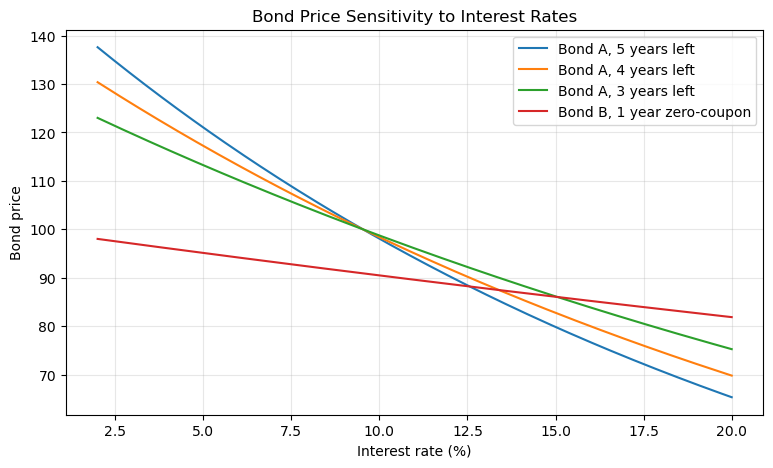

In [58]:
rates = np.linspace(0.02, 0.20, 200)

bond_A_5y = [price_bond_plot([C, C, C, C, F + C], r) for r in rates]
bond_A_4y = [price_bond_plot([C, C, C, F + C], r) for r in rates]
bond_A_3y = [price_bond_plot([C, C, F + C], r) for r in rates]
bond_B_1y = [price_bond_plot([F], r) for r in rates]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(rates * 100, bond_A_5y, label="Bond A, 5 years left")
ax.plot(rates * 100, bond_A_4y, label="Bond A, 4 years left")
ax.plot(rates * 100, bond_A_3y, label="Bond A, 3 years left")
ax.plot(rates * 100, bond_B_1y, label="Bond B, 1 year zero-coupon")

ax.set_title("Bond Price Sensitivity to Interest Rates")
ax.set_xlabel("Interest rate (%)")
ax.set_ylabel("Bond price")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

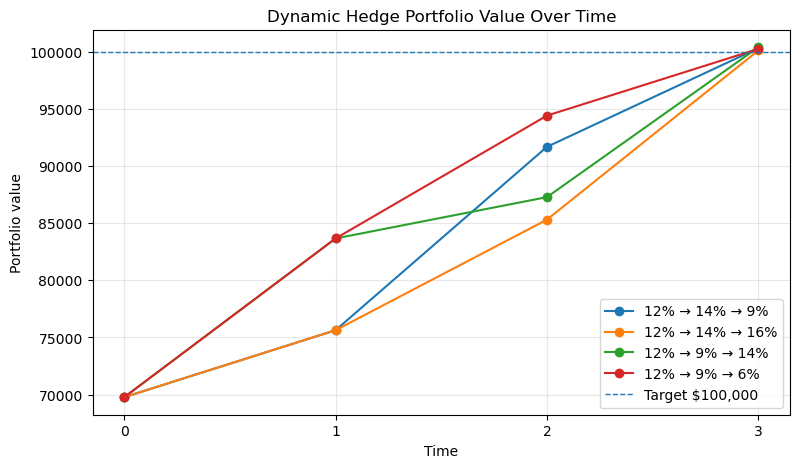

In [59]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, result in dynamic_results.items():
    ax.plot(
        result["times"],
        result["values"],
        marker="o",
        label=label
    )

ax.axhline(TARGET, linestyle="--", linewidth=1, label="Target $100,000")

ax.set_title("Dynamic Hedge Portfolio Value Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Portfolio value")
ax.set_xticks([0, 1, 2, 3])
ax.legend()
ax.grid(alpha=0.3)

plt.show()

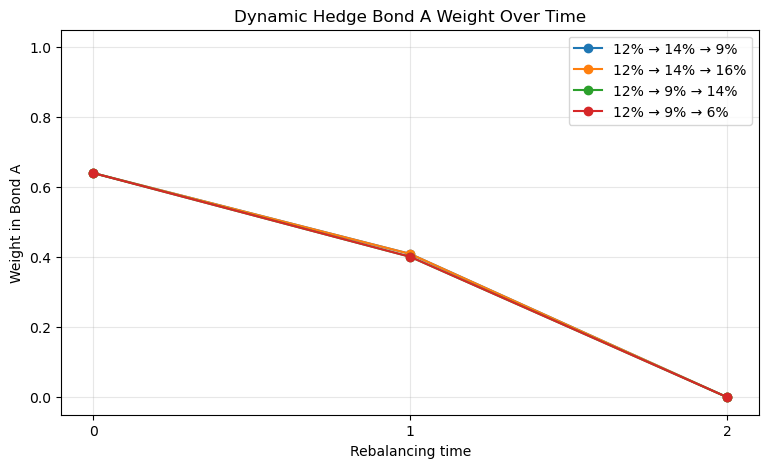

In [60]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, result in dynamic_results.items():
    ax.plot(
        result["rebalance_times"],
        result["weights"][:, 0],
        marker="o",
        label=label
    )

ax.set_title("Dynamic Hedge Bond A Weight Over Time")
ax.set_xlabel("Rebalancing time")
ax.set_ylabel("Weight in Bond A")
ax.set_xticks([0, 1, 2])
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

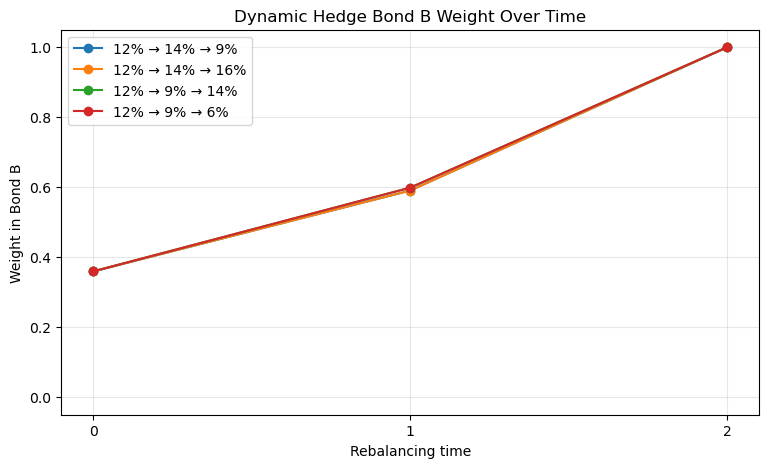

In [61]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, result in dynamic_results.items():
    ax.plot(
        result["rebalance_times"],
        result["weights"][:, 1],
        marker="o",
        label=label
    )

ax.set_title("Dynamic Hedge Bond B Weight Over Time")
ax.set_xlabel("Rebalancing time")
ax.set_ylabel("Weight in Bond B")
ax.set_xticks([0, 1, 2])
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

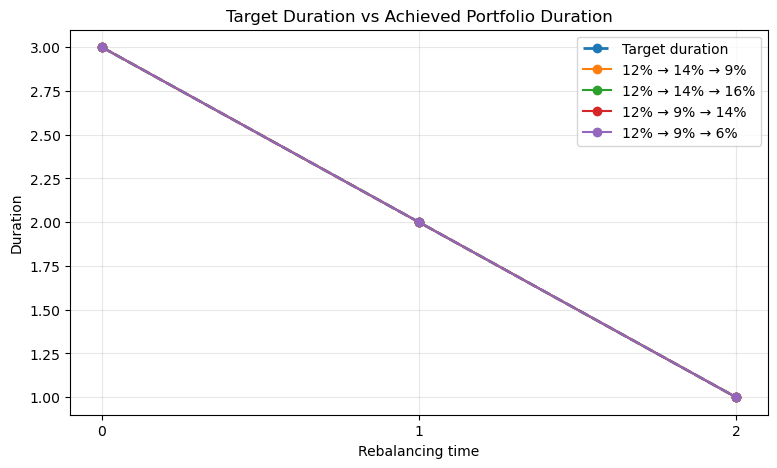

In [62]:
target_duration = np.array([3, 2, 1])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    [0, 1, 2],
    target_duration,
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Target duration"
)

for label, result in dynamic_results.items():
    ax.plot(
        result["rebalance_times"],
        result["achieved_duration"],
        marker="o",
        label=label
    )

ax.set_title("Target Duration vs Achieved Portfolio Duration")
ax.set_xlabel("Rebalancing time")
ax.set_ylabel("Duration")
ax.set_xticks([0, 1, 2])
ax.legend()
ax.grid(alpha=0.3)

plt.show()

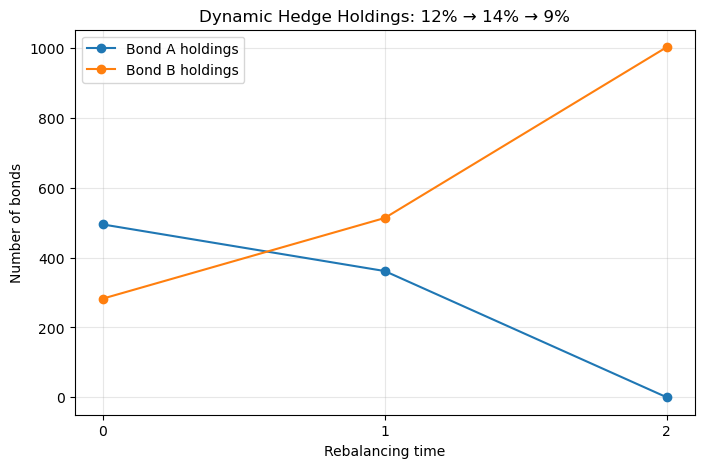

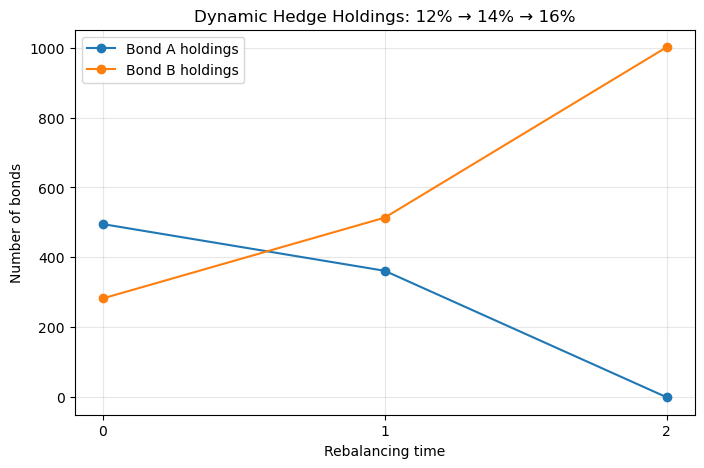

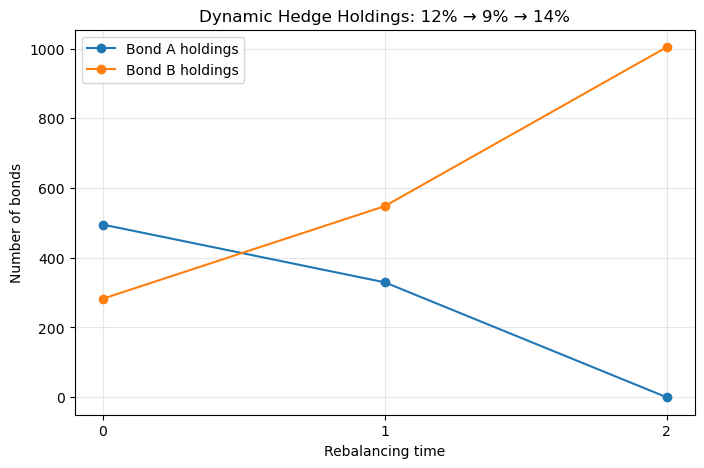

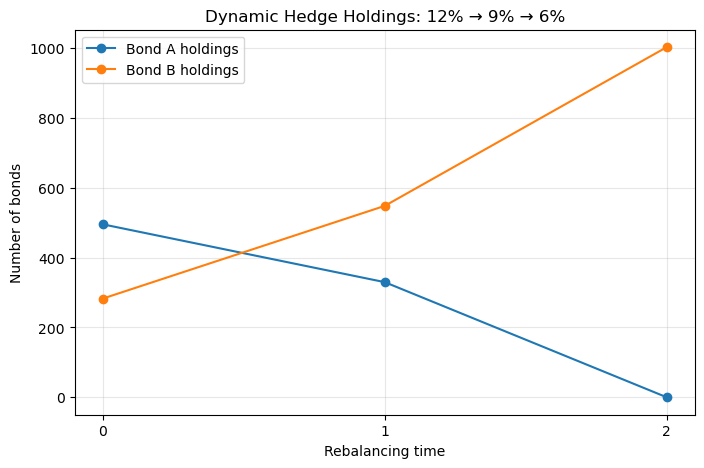

In [63]:
for label, result in dynamic_results.items():
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        result["rebalance_times"],
        result["holdings"][:, 0],
        marker="o",
        label="Bond A holdings"
    )

    ax.plot(
        result["rebalance_times"],
        result["holdings"][:, 1],
        marker="o",
        label="Bond B holdings"
    )

    ax.set_title(f"Dynamic Hedge Holdings: {label}")
    ax.set_xlabel("Rebalancing time")
    ax.set_ylabel("Number of bonds")
    ax.set_xticks([0, 1, 2])
    ax.legend()
    ax.grid(alpha=0.3)

    plt.show()

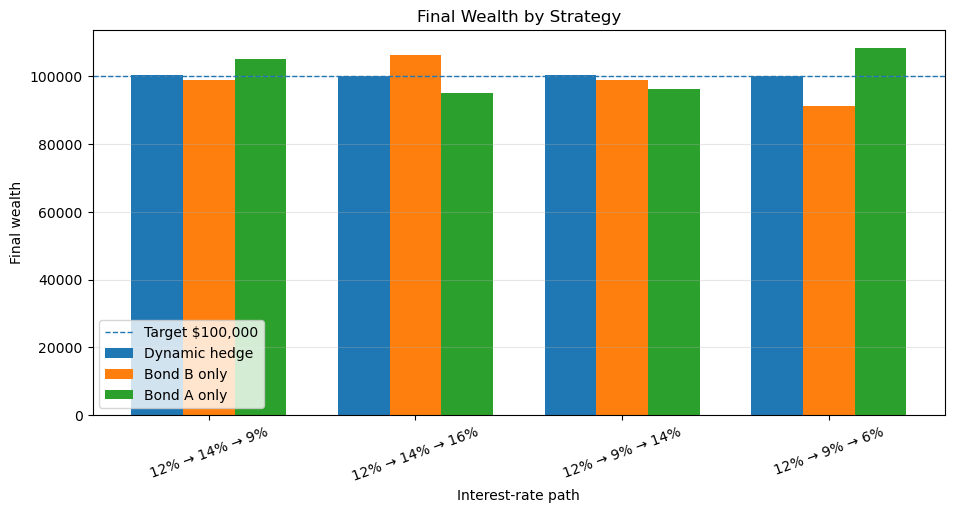

In [64]:
labels = list(PATHS.keys())
x = np.arange(len(labels))
width = 0.25

dynamic_final = [dynamic_results[label]["values"][-1] for label in labels]
bond_b_final = [bond_b_results[label]["values"][-1] for label in labels]
bond_a_final = [bond_a_results[label]["values"][-1] for label in labels]

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(x - width, dynamic_final, width, label="Dynamic hedge")
ax.bar(x, bond_b_final, width, label="Bond B only")
ax.bar(x + width, bond_a_final, width, label="Bond A only")

ax.axhline(TARGET, linestyle="--", linewidth=1, label="Target $100,000")

ax.set_title("Final Wealth by Strategy")
ax.set_xlabel("Interest-rate path")
ax.set_ylabel("Final wealth")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.show()

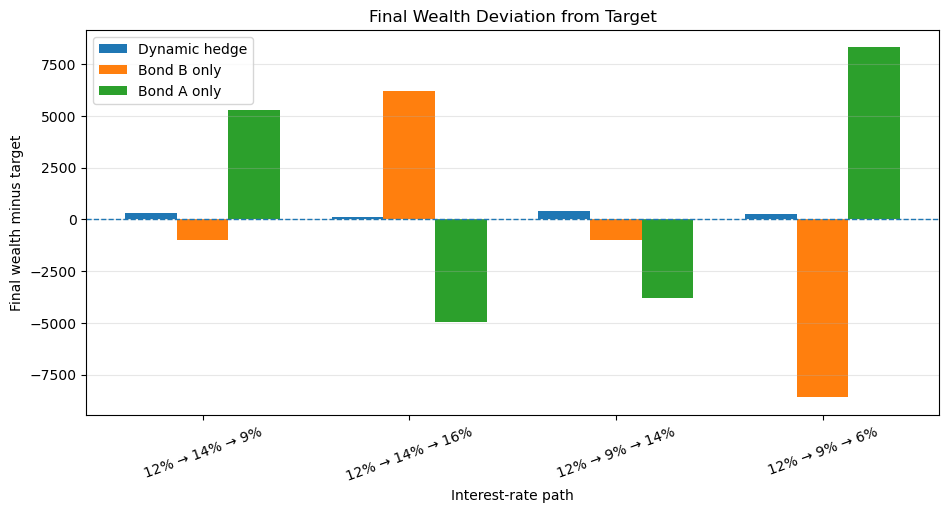

In [65]:
dynamic_error = np.array(dynamic_final) - TARGET
bond_b_error = np.array(bond_b_final) - TARGET
bond_a_error = np.array(bond_a_final) - TARGET

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(x - width, dynamic_error, width, label="Dynamic hedge")
ax.bar(x, bond_b_error, width, label="Bond B only")
ax.bar(x + width, bond_a_error, width, label="Bond A only")

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_title("Final Wealth Deviation from Target")
ax.set_xlabel("Interest-rate path")
ax.set_ylabel("Final wealth minus target")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.show()

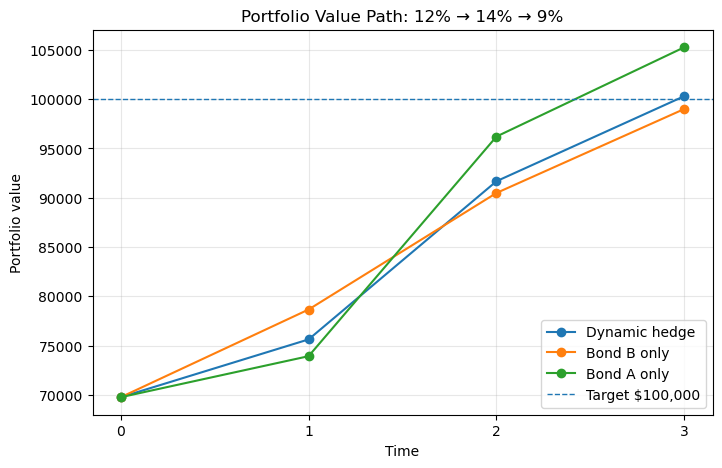

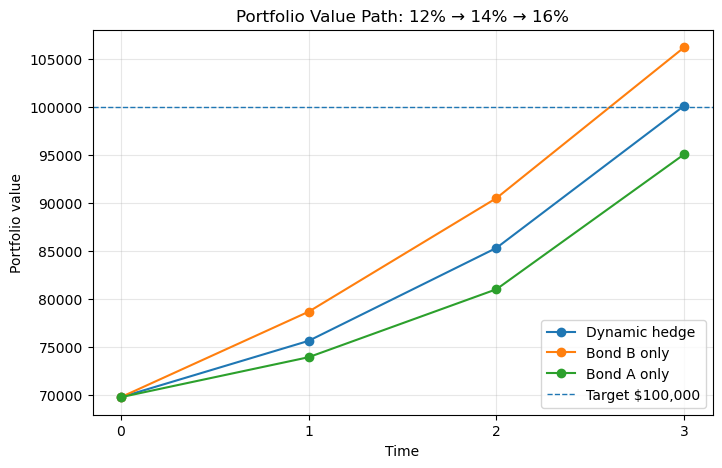

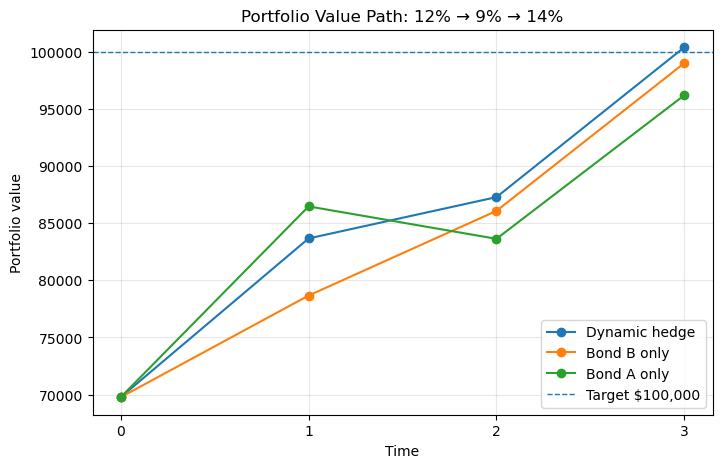

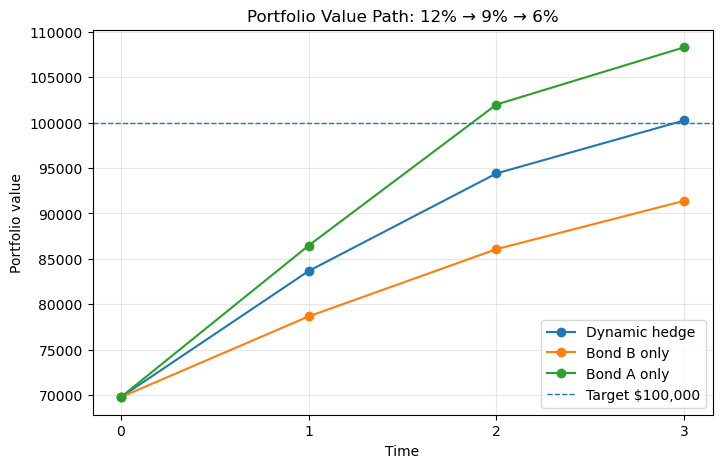

In [66]:
for label in PATHS:
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        dynamic_results[label]["times"],
        dynamic_results[label]["values"],
        marker="o",
        label="Dynamic hedge"
    )

    ax.plot(
        bond_b_results[label]["times"],
        bond_b_results[label]["values"],
        marker="o",
        label="Bond B only"
    )

    ax.plot(
        bond_a_results[label]["times"],
        bond_a_results[label]["values"],
        marker="o",
        label="Bond A only"
    )

    ax.axhline(TARGET, linestyle="--", linewidth=1, label="Target $100,000")

    ax.set_title(f"Portfolio Value Path: {label}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Portfolio value")
    ax.set_xticks([0, 1, 2, 3])
    ax.legend()
    ax.grid(alpha=0.3)

    plt.show()